Creacion De Image

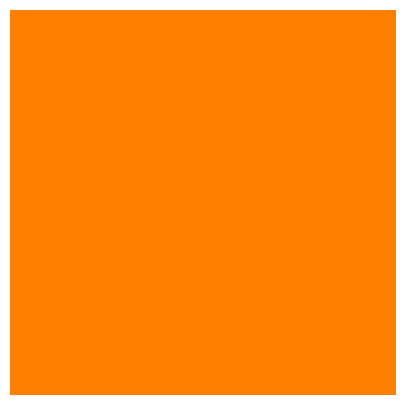

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]
path="imagenes/original/gato.jpeg"
tamano_imagen=100
R=np.ones((tamano_imagen,tamano_imagen))*255
G=np.ones((tamano_imagen,tamano_imagen))*128
B=np.ones((tamano_imagen,tamano_imagen))*0
imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)
plt.axis('off')
plt.imshow(imagen)
plt.show()


Escala de grises y profundidad del color

uint8
uint16


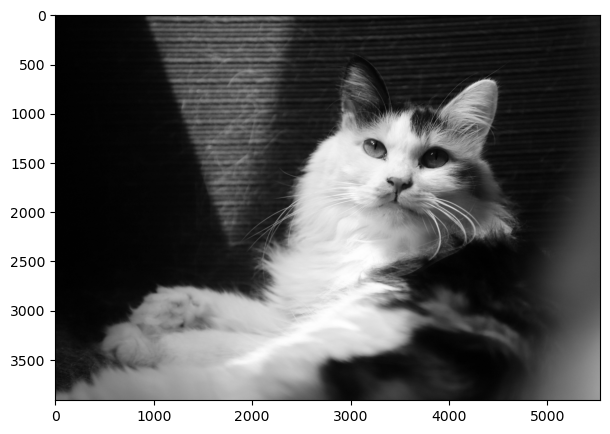

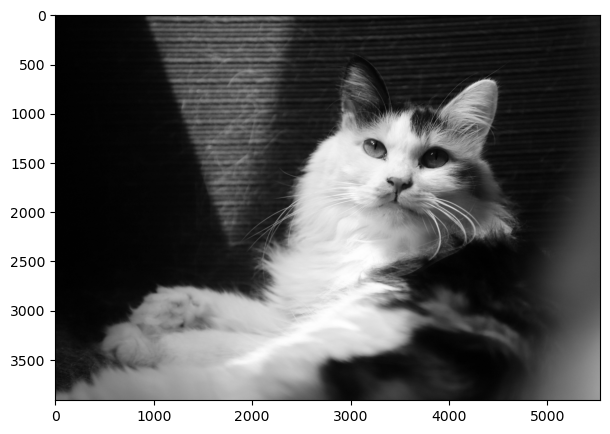

True

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]
path="imagenes/original/gato.jpeg"
imagen=cv2.imread(path,cv2.IMREAD_GRAYSCALE)
img_inicial=imagen.dtype#valor de profundidad
print(img_inicial)
img_16bit=np.uint16(imagen)
img_nueva=img_16bit.dtype
print(img_nueva)
plt.imshow(imagen,cmap="gray")
plt.show()
plt.imshow(img_16bit, cmap='gray')
plt.show()
cv2.imwrite("imagenes/gr_prof_color/gato2.jpeg", img_16bit)


RGB a HSV

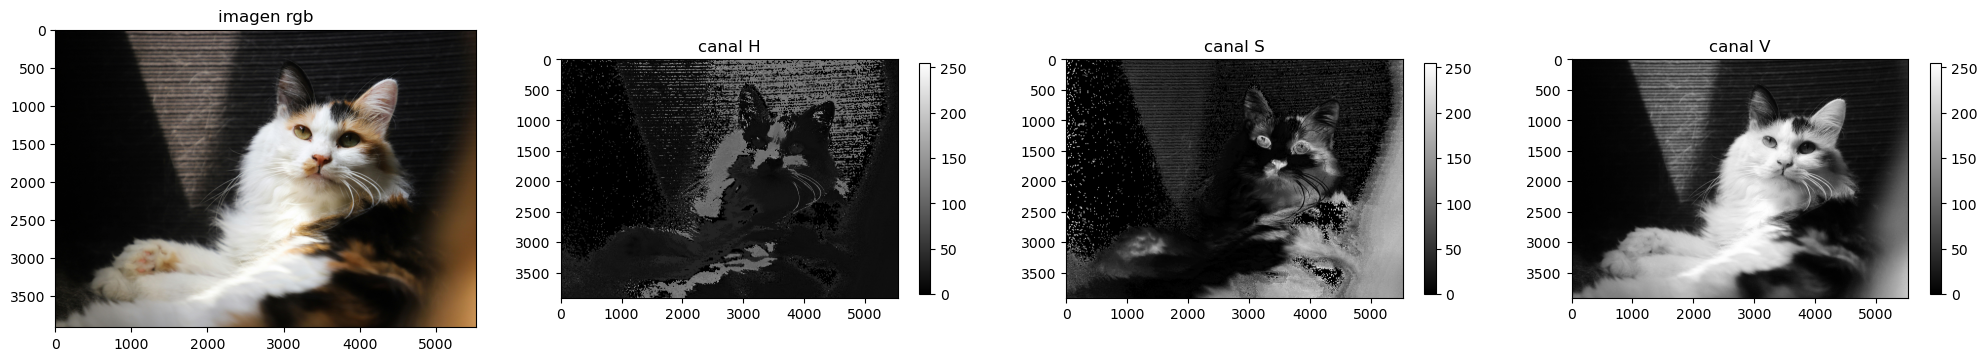

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]
fig,axs=plt.subplots(1,4,figsize=(25,10))
path="imagenes/original/gato.jpeg"
imagen=cv2.imread(path)
img_rgb=cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

axs[0].imshow(img_rgb)
axs[0].set_title("imagen rgb")


fig_img1=axs[1].imshow(hsv[...,0],cmap="gray",vmin=0,vmax=255)
fig.colorbar(fig_img1,ax=axs[1],shrink=0.3)
axs[1].set_title("canal H")


fig_img2=axs[2].imshow(hsv[...,1],cmap="gray",vmin=0,vmax=255)
fig.colorbar(fig_img1,ax=axs[2],shrink=0.3)
axs[2].set_title("canal S")


fig_img3=axs[3].imshow(hsv[...,2],cmap="gray",vmin=0,vmax=255)
fig.colorbar(fig_img3,ax=axs[3],shrink=0.3)
axs[3].set_title("canal V")


plt.show()

crea una imagen en RGB que contenga 4 cuadrantes , en rojo,verde,azul y negro

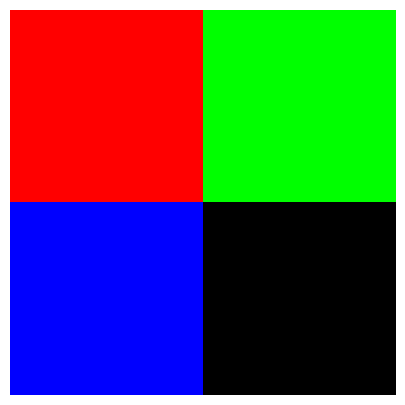

True

In [70]:
import numpy as np
import matplotlib.pyplot as plt

tamano_imagen = 100
imagen = np.zeros((tamano_imagen, tamano_imagen, 3), dtype=int)
imagen[:tamano_imagen//2, :tamano_imagen//2] = [255, 0, 0]
imagen[:tamano_imagen//2, tamano_imagen//2:] = [0, 255, 0]
imagen[tamano_imagen//2:, :tamano_imagen//2] = [0, 0, 255]
plt.axis('off')
plt.imshow(imagen)
plt.show()
cv2.imwrite("imagenes/gr_prof_color/cuadrantes.jpeg", img_16bit)

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Estudiante\AppData\Local\Temp\ipykernel_18112\1910515160.py:2: SyntaxWarning: invalid escape sequence '\g'
  Imagen = cv2.imread('imagenes\gr_prof_color\gato2.jpeg')
C:\Users\Estudiante\AppData\Local\Temp\ipykernel_18112\1910515160.py:30: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


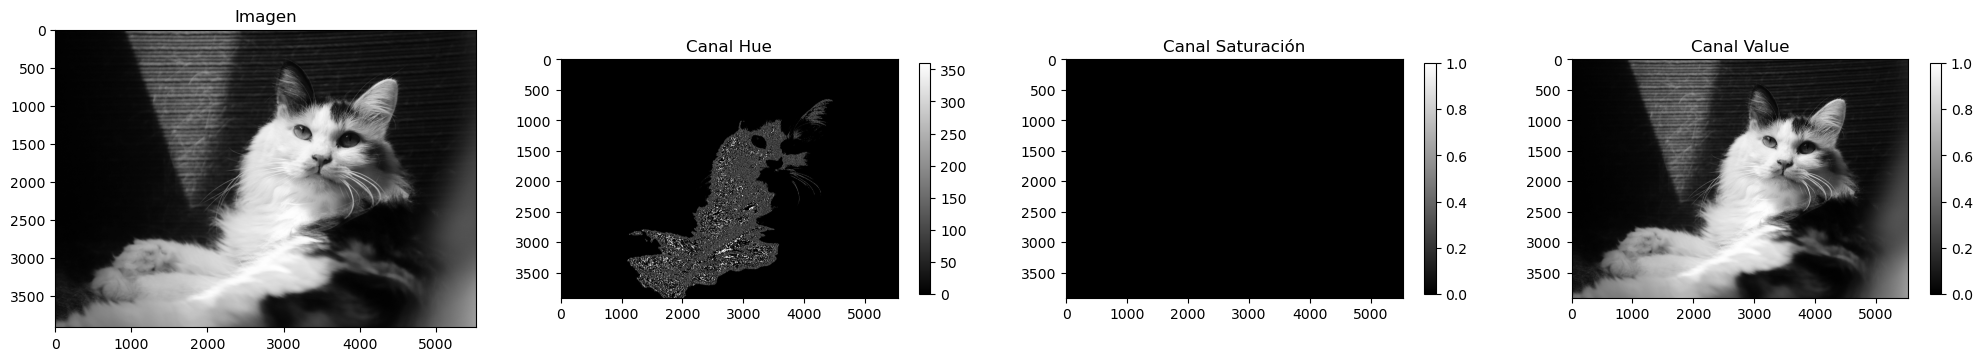

In [4]:
import numpy as np
Imagen = cv2.imread('imagenes\gr_prof_color\gato2.jpeg')
img= cv2.cvtColor(Imagen, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        bol_ind = new_img[...,0] < 0
        new_img[bol_ind,0]   =  new_img[bol_ind,0] + 360
    return new_img 

hsv_img =  RGB2HSV(img) 
fig, axs = plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen')
fig_img = axs[1].imshow(hsv_img[...,0],cmap='gray',vmin=0,vmax=360)
fig.colorbar(fig_img, ax=axs[1],shrink=0.3)
axs[1].set_title('Canal Hue')
fig_img = axs[2].imshow(hsv_img[...,1],cmap='gray',vmin=0,vmax=1)
fig.colorbar(fig_img, ax=axs[2],shrink=0.3)
axs[2].set_title('Canal Saturación')
fig_img = axs[3].imshow(hsv_img[...,2],cmap='gray',vmin=0,vmax=1)
fig.colorbar(fig_img, ax=axs[3],shrink=0.3)
axs[3].set_title('Canal Value');


hcv argb

In [ ]:
def HSV2RGB(img):
    new_img = np.zeros_like(img)
    
    C = img[...,2]*img[...,1]
    X = C*(1-abs((img[...,0]/60)%2-1))
    m = img[...,2]-C

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            h = img[i,j,0]
            if 0 <= h and h < 60:
                new_img[i,j] = C[i,j],X[i,j],0
            elif 60 <= h and h < 120:
                new_img[i,j] = X[i,j],C[i,j],0
            elif 120 <= h and h < 180:
                new_img[i,j] = 0,C[i,j],X[i,j]
            elif 180 <= h and h < 240:
                new_img[i,j] = 0,X[i,j],C[i,j]
            elif 240 <= h and h < 300:
                new_img[i,j] = X[i,j],0,C[i,j]
            elif 300 <= h and h < 360:
                new_img[i,j] = C[i,j],0,X[i,j]
    new_img[...,0] = (new_img[...,0]+m)*255
    new_img[...,1] = (new_img[...,1]+m)*255
    new_img[...,2] = (new_img[...,2]+m)*255
    new_img = new_img.astype(int)
    return new_img 
rgb_img =   HSV2RGB(hsv_img) 
fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen')


fig_img = axs[1].imshow(rgb_img[...,0],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[1],shrink=0.3)
axs[1].set_title('Canal Rojo')


fig_img = axs[2].imshow(rgb_img[...,1],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[2],shrink=0.3)
axs[2].set_title('Canal Verde')


fig_img = axs[3].imshow(rgb_img[...,2],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[3],shrink=0.3)
axs[3].set_title('Canal Azul');

<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Estudiante\AppData\Local\Temp\ipykernel_18112\2117296717.py:5: SyntaxWarning: invalid escape sequence '\g'
  img_rgb=cv2.cvtColor(cv2.imread('imagenes\gr_prof_color\gato2.jpeg',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)


Text(0.5, 1.0, 'imagen rgb2')

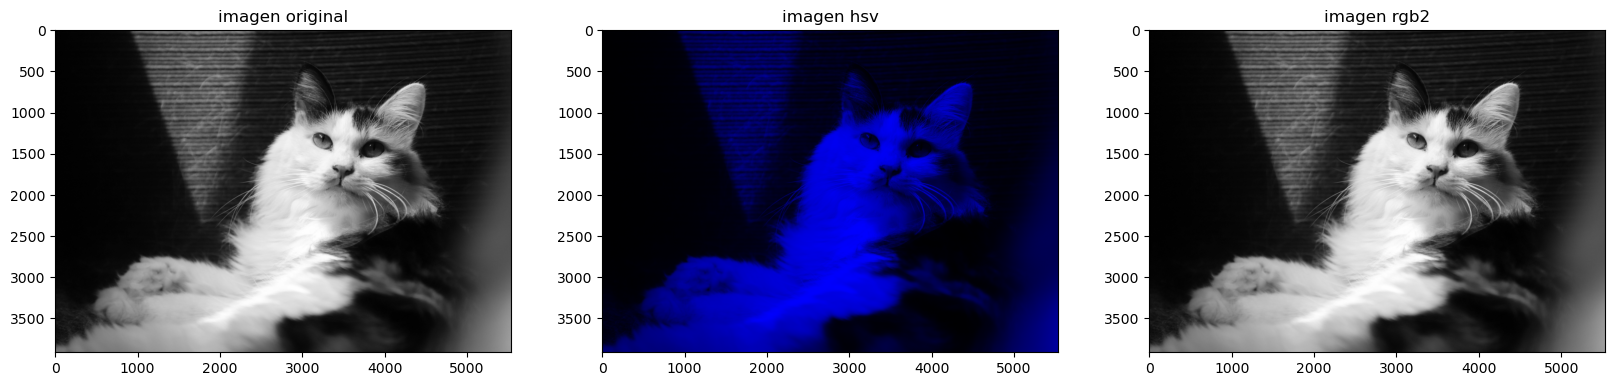

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_rgb=cv2.cvtColor(cv2.imread('imagenes\gr_prof_color\gato2.jpeg',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)
img_hsv=cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)
img_rgb2=cv2.cvtColor(img_hsv,cv2.COLOR_HSV2BGR)
fig,axs=plt.subplots(1,3,figsize=(20,10))

axs[0].imshow(img_rgb)
axs[0].set_title("imagen original")

axs[1].imshow(img_hsv)
axs[1].set_title("imagen hsv")

axs[2].imshow(img_rgb2)
axs[2].set_title("imagen rgb2")



<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Estudiante\AppData\Local\Temp\ipykernel_18112\2608391259.py:5: SyntaxWarning: invalid escape sequence '\g'
  imagen=cv2.imread('imagenes\gr_prof_color\gato2.jpeg',0)


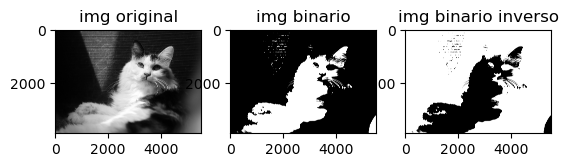

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

imagen=cv2.imread('imagenes\gr_prof_color\gato2.jpeg',0)
_,umbralbinario=cv2.threshold(imagen,124,255,cv2.THRESH_BINARY)
_,umbralbinarioInverso=cv2.threshold(imagen,124,255,cv2.THRESH_BINARY_INV)

plt.subplot(1,3,1)
plt.imshow(imagen,cmap="gray")
plt.title("img original")

plt.subplot(1,3,2)
plt.imshow(umbralbinario,cmap="gray")
plt.title("img binario")

plt.subplot(1,3,3)
plt.imshow(umbralbinarioInverso,cmap="gray")
plt.title("img binario inverso")
plt.show()